# 1_EDA_RegresionLogistica

**Proyecto:** FinanceGuard — Avance #1  

En este notebook hago un EDA básico, preparo los datos y entreno una regresión logística como baseline. Voy explicando por qué hago cada bloque de código y qué busco con ello.



In [5]:
# 0. Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve,
    precision_score, recall_score, f1_score, auc
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Opcional: SMOTE si se instala
# from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
%matplotlib inline

## 1) Carga de datos



In [6]:

df = pd.read_csv('C:\\Users\\Davem\\Downloads\\DATA SCIENCE\\Modulo_4\\ProyectoM4_Lourdes_Diamela_Alarcon_DSFT01\\Churn_Modelling.csv')
print("Shape (filas, columnas):", df.shape)
display(df.head())

Shape (filas, columnas): (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2) Revisión rápida: info, nulos y distribución objetivo

Quiero verificar tipos de datos, nulos y cómo está distribuida la variable objetivo (Exited / churn).

In [7]:
print('INFO DEL DATAFRAME:')
display(df.info())

print('\nNulos por columna:')
display(df.isna().sum())

# Detecto el nombre de la columna objetivo
if 'Exited' in df.columns:
    target_col = 'Exited'
elif 'churn' in df.columns:
    target_col = 'churn'
else:
    raise ValueError("No encuentro la columna objetivo 'Exited' o 'churn' en el dataset.")

print(f"\nLa columna objetivo detectada es: {target_col}")
vc = df[target_col].value_counts()
display(vc, (vc / len(df)).round(3))

print('Total clientes:', len(df))

INFO DEL DATAFRAME:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


None


Nulos por columna:


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


La columna objetivo detectada es: Exited


Exited
0    7963
1    2037
Name: count, dtype: int64

Exited
0    0.796
1    0.204
Name: count, dtype: float64

Total clientes: 10000


## 3) EDA básico, gráficos y relaciones

Hago gráficos esenciales para entender la distribución de las variables clave y su relación con churn.

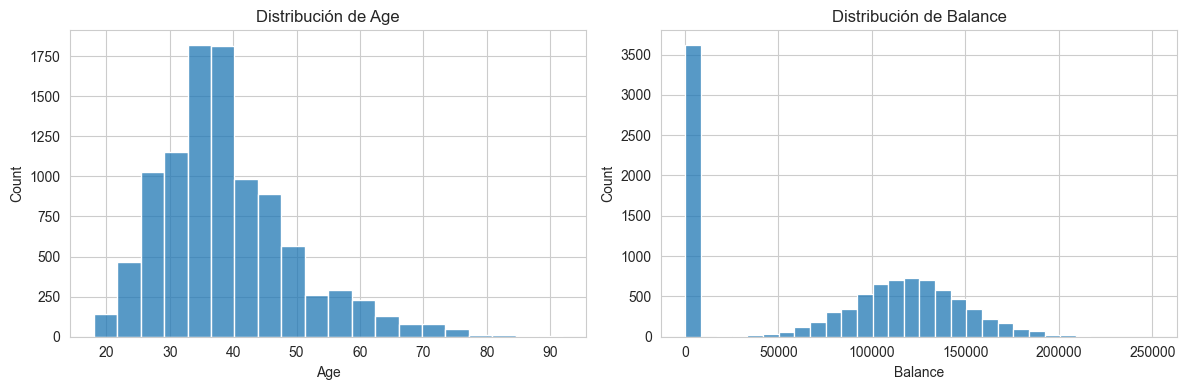

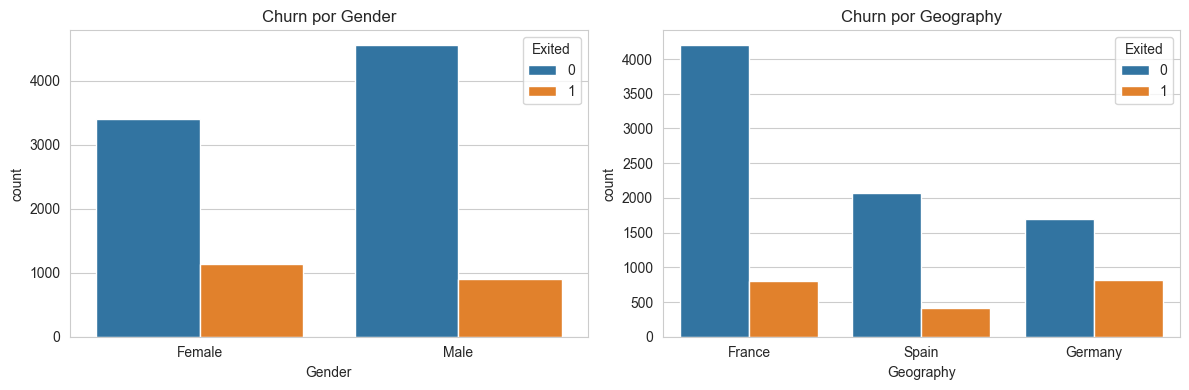

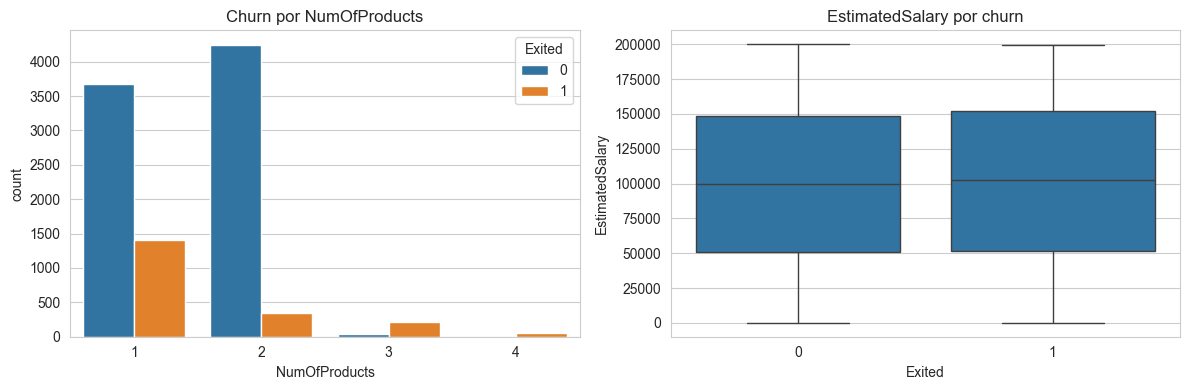

In [8]:
# Histograma Age y Balance (si existen)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
if 'Age' in df.columns:
    sns.histplot(df['Age'], bins=20, kde=False)
    plt.title('Distribución de Age')
else:
    plt.text(0.5, 0.5, 'No hay columna Age', ha='center')

plt.subplot(1,2,2)
if 'Balance' in df.columns:
    sns.histplot(df['Balance'], bins=30, kde=False)
    plt.title('Distribución de Balance')
else:
    plt.text(0.5, 0.5, 'No hay columna Balance', ha='center')
plt.tight_layout()
plt.show()

# Countplot churn por Gender y Geography (si existen)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
if 'Gender' in df.columns:
    sns.countplot(x='Gender', hue=target_col, data=df)
    plt.title('Churn por Gender')
else:
    plt.text(0.5, 0.5, 'No hay columna Gender', ha='center')

plt.subplot(1,2,2)
if 'Geography' in df.columns:
    sns.countplot(x='Geography', hue=target_col, data=df)
    plt.title('Churn por Geography')
else:
    plt.text(0.5, 0.5, 'No hay columna Geography', ha='center')
plt.tight_layout()
plt.show()

# Churn vs NumOfProducts y EstimatedSalary
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
if 'NumOfProducts' in df.columns:
    sns.countplot(x='NumOfProducts', hue=target_col, data=df)
    plt.title('Churn por NumOfProducts')
else:
    plt.text(0.5, 0.5, 'No hay columna NumOfProducts', ha='center')

plt.subplot(1,2,2)
if 'EstimatedSalary' in df.columns:
    sns.boxplot(x=target_col, y='EstimatedSalary', data=df)
    plt.title('EstimatedSalary por churn')
else:
    plt.text(0.5, 0.5, 'No hay columna EstimatedSalary', ha='center')
plt.tight_layout()
plt.show()

## 4) Correlación preliminar entre variables numéricas (heatmap)

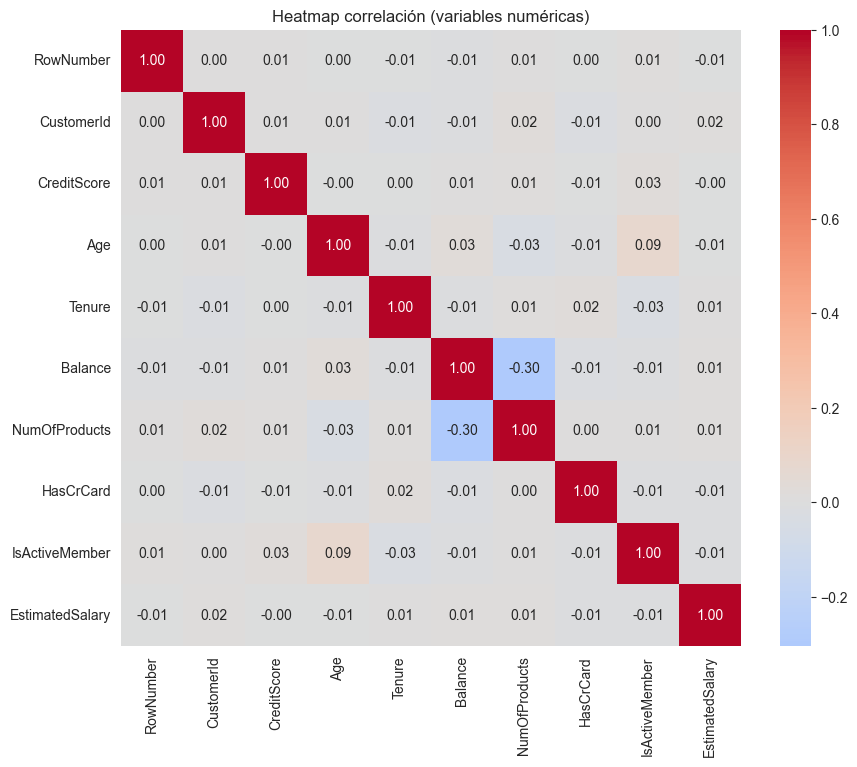

In [9]:
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols_all:
    num_cols_all.remove(target_col)

if len(num_cols_all) > 0:
    plt.figure(figsize=(10,8))
    sns.heatmap(df[num_cols_all].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Heatmap correlación (variables numéricas)')
    plt.show()
else:
    print('No hay columnas numéricas para correlación.')

## 5) Limpieza y preprocesamiento básico

- Elimino columnas irrelevantes.  
- Relleno nulos simples.  
- Hago encoding (Gender map, Geography one-hot).  
- Renombro la target a `churn` para consistencia.

In [10]:
df_proc = df.copy()

# Elimino columnas irrelevantes
for col in ['RowNumber', 'CustomerId', 'Surname']:
    if col in df_proc.columns:
        df_proc.drop(col, axis=1, inplace=True)

# Reviso nulos y relleno simple
nulos = df_proc.isna().sum()
print('Nulos por columna (post-drop):')
display(nulos[nulos>0])

# Relleno numéricos con mediana, categóricos con moda
for c in df_proc.columns:
    if df_proc[c].isna().sum() > 0:
        if df_proc[c].dtype in [np.float64, np.int64]:
            df_proc[c].fillna(df_proc[c].median(), inplace=True)
        else:
            df_proc[c].fillna(df_proc[c].mode()[0], inplace=True)

print('Nulos totales tras relleno:', df_proc.isna().sum().sum())

# Renombro target a 'churn' si se detectó 'Exited'
df_proc.rename(columns={target_col: 'churn'}, inplace=True)
target_col = 'churn'

# Encoding Gender
if 'Gender' in df_proc.columns:
    df_proc['Gender'] = df_proc['Gender'].map({'Female':0, 'Male':1})
    df_proc['Gender'].fillna(0, inplace=True)

# One-hot Geography (sin drop_first para incluir Francia)
if 'Geography' in df_proc.columns:
    df_proc = pd.get_dummies(df_proc, columns=['Geography'], drop_first=True)

display(df_proc.head())


Nulos por columna (post-drop):


Series([], dtype: int64)

Nulos totales tras relleno: 0


C:\Users\Davem\AppData\Local\Temp\ipykernel_13680\1341172073.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_proc['Gender'].fillna(0, inplace=True)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,churn,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## 6) Split train/test (80/20) estratificado y escalado

Mantengo la proporción de clases en train/test con `stratify`. Escalo con `StandardScaler` aplicando `fit` solo en train.

In [11]:
# Separar X y y
X = df_proc.drop('churn', axis=1)
y = df_proc['churn']

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Columnas numéricas a escalar
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print('Columnas numéricas detectadas:', num_cols)

# Evito SettingWithCopy
X_train = X_train.copy()
X_test = X_test.copy()

scaler = StandardScaler()
X_train.loc[:, num_cols] = scaler.fit_transform(X_train.loc[:, num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test.loc[:, num_cols])

# Reviso proporciones
print('Distribución TRAIN:')
display(y_train.value_counts(), (y_train.value_counts()/len(y_train)).round(3))
print('\nDistribución TEST:')
display(y_test.value_counts(), (y_test.value_counts()/len(y_test)).round(3))

Columnas numéricas detectadas: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


C:\Users\Davem\AppData\Local\Temp\ipykernel_13680\4208156490.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.058568   0.91362605 1.07927399 ... 0.16821031 0.37527024 1.56586482]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, num_cols] = scaler.fit_transform(X_train.loc[:, num_cols])
C:\Users\Davem\AppData\Local\Temp\ipykernel_13680\4208156490.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.90750738  0.90750738 -1.10191942 ... -1.10191942  0.90750738
  0.90750738]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, num_cols] = scaler.fit_transform(X_train.loc[:, num_cols])
C:\Users\Davem\AppData\Local\Temp\ipykernel_13680\4208156490.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise

Distribución TRAIN:


C:\Users\Davem\AppData\Local\Temp\ipykernel_13680\4208156490.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.64104192  0.64104192  0.64104192 ...  0.64104192  0.64104192
 -1.55996038]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, num_cols] = scaler.fit_transform(X_train.loc[:, num_cols])
C:\Users\Davem\AppData\Local\Temp\ipykernel_13680\4208156490.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.030206   -1.030206    0.97067965 ...  0.97067965 -1.030206
  0.97067965]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, num_cols] = scaler.fit_transform(X_train.loc[:, num_cols])
C:\Users\Davem\AppData\Local\Temp\ipykernel_13680\4208156490.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will 

churn
0    6370
1    1630
Name: count, dtype: int64

churn
0    0.796
1    0.204
Name: count, dtype: float64


Distribución TEST:


churn
0    1593
1     407
Name: count, dtype: int64

churn
0    0.796
1    0.204
Name: count, dtype: float64

## 7) Multicolinealidad: Heatmap y VIF

Calculo VIF para identificar variables con multicolinealidad fuerte.

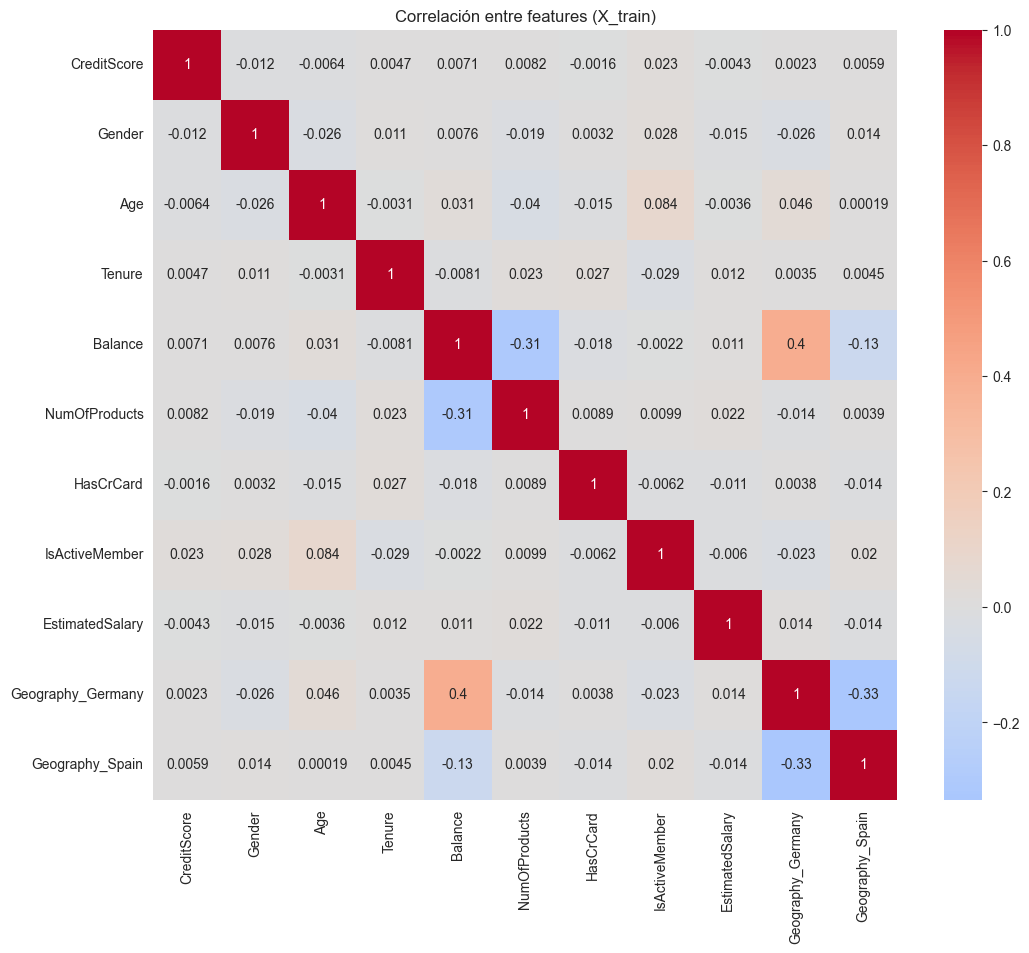

,feature,VIF
5,NumOfProducts,1.107618
4,Balance,1.105728
2,Age,1.010252
7,IsActiveMember,1.009697
1,Gender,1.002565
3,Tenure,1.002419
6,HasCrCard,1.001431
8,EstimatedSalary,1.001350
0,CreditScore,1.000992


In [12]:
# Heatmap de correlación en X_train
plt.figure(figsize=(12,10))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlación entre features (X_train)')
plt.show()

# VIF: uso las columnas numéricas detectadas antes
X_vif = X_train[num_cols].copy()
X_vif = X_vif.fillna(0)

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

display(vif_data.sort_values('VIF', ascending=False).head(30))

## 8) Regresión Logística / baseline con scikit-learn

Entreno un modelo baseline con `class_weight='balanced'` para compensar el desbalance inicial.

Accuracy: 0.7135

Classification report:
              precision    recall  f1-score   support

           0     0.9035    0.7169    0.7994      1593
           1     0.3872    0.7002    0.4987       407

    accuracy                         0.7135      2000
   macro avg     0.6454    0.7086    0.6491      2000
weighted avg     0.7984    0.7135    0.7382      2000



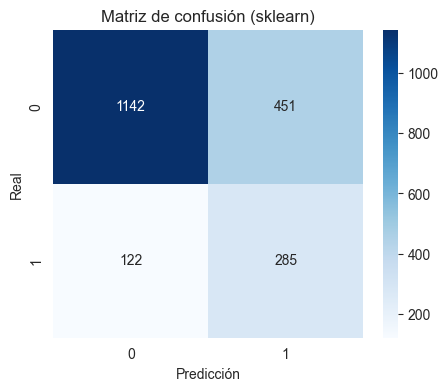

ROC AUC (sklearn model): 0.7771762517525229


In [13]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# Métricas básicas
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión (sklearn)')
plt.show()

print('ROC AUC (sklearn model):', roc_auc_score(y_test, y_proba))

## 9) Ajuste con statsmodels para interpretar coeficientes, odds ratios e intervalos de confianza

Antes de ajustar me aseguro que todas las columnas sean numéricas y que índices coincidan. Statsmodels es estricto con tipos.

In [14]:
# Asegurar que X_train y X_test sean numéricos
def ensure_numeric_df(df_in):
    df_out = df_in.copy()
    for col in df_out.columns:
        if df_out[col].dtype == 'object' or str(df_out[col].dtype).startswith('category'):
            df_out[col] = pd.to_numeric(df_out[col], errors='coerce')
        if df_out[col].dtype == 'bool':
            df_out[col] = df_out[col].astype(int)
    return df_out

X_train_num = ensure_numeric_df(X_train)
X_test_num = ensure_numeric_df(X_test)

# Verifico NaNs
nans_train = X_train_num.isna().sum().sum()
nans_test = X_test_num.isna().sum().sum()
print('NaNs generados en X_train_num:', nans_train)
print('NaNs generados en X_test_num:', nans_test)

# Relleno NaNs con 0 para statsmodels
X_train_num = X_train_num.fillna(0)
X_test_num = X_test_num.fillna(0)

# Reinicio índices para statsmodels
X_train_num = X_train_num.reset_index(drop=True)
y_train_sm = y_train.reset_index(drop=True).astype(float)

# Agrego constante y convierto a float
X_train_sm = sm.add_constant(X_train_num).astype(float)

# Ajusto Logit
logit_sm = sm.Logit(y_train_sm, X_train_sm)
result = logit_sm.fit(disp=False)
print(result.summary())

# Extraigo coeficientes, CIs y p-values
coefs = result.params
conf = result.conf_int()
pvals = result.pvalues

summary_df = pd.DataFrame({
    'feature': coefs.index,
    'coef': coefs.values,
    'odds_ratio': np.exp(coefs.values),
    'ci_lower': np.exp(conf[0]),
    'ci_upper': np.exp(conf[1]),
    'p_value': pvals.values
}).reset_index(drop=True)

display(summary_df.sort_values('odds_ratio', ascending=False).head(30))

NaNs generados en X_train_num: 0
NaNs generados en X_test_num: 0
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7988
Method:                           MLE   Df Model:                           11
Date:                Mon, 24 Nov 2025   Pseudo R-squ.:                  0.1511
Time:                        20:33:40   Log-Likelihood:                -3433.3
converged:                       True   LL-Null:                       -4044.5
Covariance Type:            nonrobust   LLR p-value:                2.584e-255
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.8644      0.049    -38.120      0.000      -1.960      -1.769
CreditScore          -0.0861      0.030     -

,feature,coef,odds_ratio,ci_lower,ci_upper,p_value
10,Geography_Germany,0.824646,2.281074,1.967129,2.645122,9.714198e-28
3,Age,0.739704,2.095315,1.975961,2.221878,6.552110e-135
5,Balance,0.160467,1.174059,1.094213,1.259733,7.991024e-06
9,EstimatedSalary,0.047806,1.048967,0.988228,1.113440,1.162193e-01
11,Geography_Spain,0.044737,1.045752,0.896043,1.220475,5.703685e-01
4,Tenure,-0.020146,0.980055,0.923789,1.039749,5.042355e-01
7,HasCrCard,-0.032258,0.968257,0.912785,1.027101,2.838831e-01
6,NumOfProducts,-0.070587,0.931847,0.877304,0.989779,2.180203e-02
1,CreditScore,-0.086082,0.917519,0.864752,0.973505,4.391973e-03
2,Gender,-0.261176,0.770145,0.725773,0.817231,6.344208e-18


### Interpretación breve

- **coef**: efecto en log-odds; coef > 0 aumenta la probabilidad de churn.  
- **odds_ratio**: más intuitivo; >1 incrementa probabilidad, <1 reduce.  
- **intervalos CI**: si incluyen 1, el efecto no es concluyente.  

En la entrega escribe interpretaciones para las 5 variables con mayor |coef| y comenta business implications.

## 10) ROC, AUC y Precision-Recall

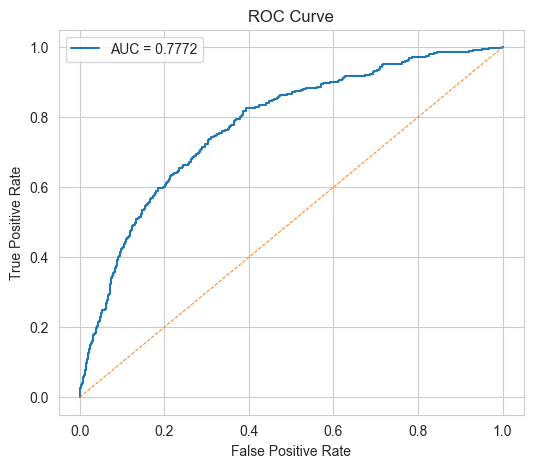

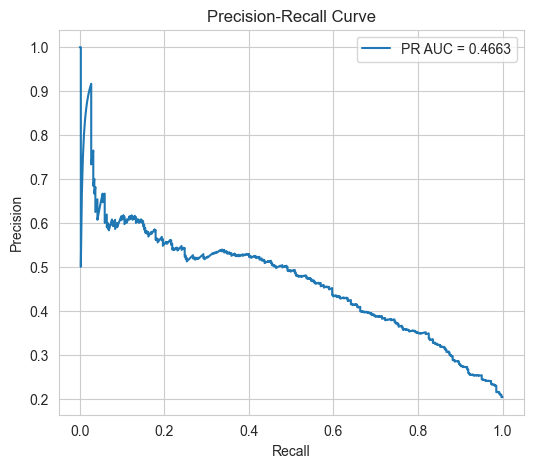

ROC AUC: 0.7772   |   PR AUC: 0.4663


In [15]:
# ROC y AUC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'--', linewidth=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# PR curve
precision, recall, pr_thresh = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

print(f'ROC AUC: {roc_auc:.4f}   |   PR AUC: {pr_auc:.4f}')

## 11) Búsqueda de threshold óptimo (maximizar F1) y métricas finales

Mejor threshold (max F1): 0.5800000000000001 con F1 = 0.5137420718816068

Reporte con threshold óptimo:
              precision    recall  f1-score   support

           0     0.8877    0.8142    0.8494      1593
           1     0.4508    0.5971    0.5137       407

    accuracy                         0.7700      2000
   macro avg     0.6693    0.7056    0.6816      2000
weighted avg     0.7988    0.7700    0.7811      2000



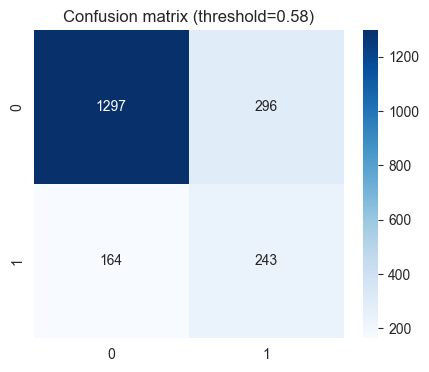

Precision: 0.45083487940630795
Recall: 0.597051597051597
F1: 0.5137420718816068


In [16]:
thresholds = np.linspace(0.01, 0.99, 99)
f1_scores = []

for t in thresholds:
    preds_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds_t))

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
print('Mejor threshold (max F1):', best_threshold, 'con F1 =', best_f1)

# Evaluación con mejor threshold
y_pred_best = (y_proba >= best_threshold).astype(int)
print('\nReporte con threshold óptimo:')
print(classification_report(y_test, y_pred_best, digits=4))

cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion matrix (threshold={best_threshold:.2f})')
plt.show()

# Métricas claves
print('Precision:', precision_score(y_test, y_pred_best))
print('Recall:', recall_score(y_test, y_pred_best))
print('F1:', f1_score(y_test, y_pred_best))

## 12) Implementación didáctica: la función sigmoide

Breve implementación para mostrar cómo se transforma el logit en probabilidad.

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_loss(y, y_hat):
    eps = 1e-9
    return -np.mean(y * np.log(y_hat + eps) + (1-y) * np.log(1-y_hat + eps))

# Demo con dos features 
features_demo = X_train.columns[:2].tolist()
if len(features_demo) == 2:
    Xd = X_train[features_demo].values
    yd = y_train.values
    Xd = np.hstack([np.ones((Xd.shape[0],1)), Xd])
    w = np.zeros(Xd.shape[1])
    lr = 0.1
    for i in range(2000):
        y_hat = sigmoid(Xd @ w)
        grad = Xd.T @ (y_hat - yd) / len(yd)
        w -= lr * grad
    print('Pesos demo (intercept, f1, f2):', w)
    print('Loss demo:', logistic_loss(yd, sigmoid(Xd @ w)))
else:
    print('No hay suficientes features para demo de regresión desde cero (se requieren 2).')

Pesos demo (intercept, f1, f2): [-1.3856938  -0.08841676 -0.2634768 ]
Loss demo: 0.49934354762676436


## 13) Conclusiones del Avance #1 (primera persona, breve)

- Entendí y documenté el problema de churn: en este dataset la tasa es ≈ 20% (ver cell de distribución).  
- Realicé EDA básico: distribuciones y relaciones por género, geografía, número de productos y salarios.  
- Limpié y procesé los datos: eliminé columnas irrelevantes, rellené nulos, convertí categóricas y escalé numéricas.  
- Identifiqué potencial multicolinealidad con VIF y heatmap (revisar variables con VIF alto).  
- Entrené una regresión logística como baseline (sklearn) y la interpreté con statsmodels (coeficientes, odds ratios, CIs y p-values).  
- Evalué con matriz de confusión, classification_report, ROC AUC y PR AUC.  
- Busqué un threshold óptimo maximizando F1 y re-evalué las métricas.  

